<a href="https://colab.research.google.com/github/SlepenkovaDaria/My-homework/blob/main/FourthDZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Temporal patterns in flight delays

In this section I analyze how flight delays vary depending on time-related factors. I want to determine whether delays are distributed evenly or if there are specific periods when they become significantly worse. Let's examine three temporal dimensions:
*   Time of day
*   Day of the week
*   Month of the year

Understanding these patterns allows us to identify periods of increased operational risk and can help the Ministry of Transport develop measures to better distribute traffic and reduce congestion in the aviation system.

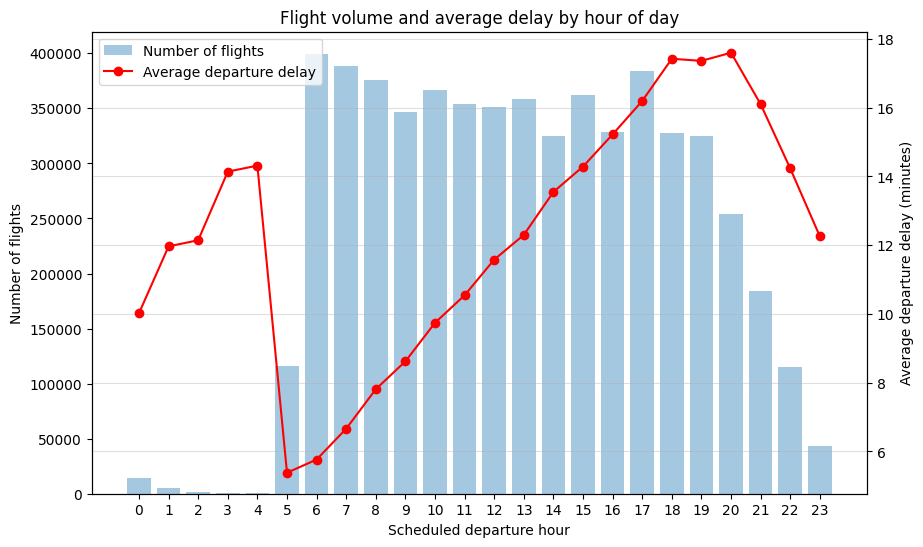

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/flights.csv", low_memory = False)
df["DEPARTURE_HOUR"] = df["SCHEDULED_DEPARTURE"] // 100

df_delays = df[df["CANCELLED"] == 0].copy()
df_delays["DEPARTURE_DELAY_POSITIVE"] = df_delays["DEPARTURE_DELAY"].clip(lower = 0)

hour_delay = df_delays.groupby("DEPARTURE_HOUR")["DEPARTURE_DELAY_POSITIVE"].mean()
hour_flights = df_delays.groupby("DEPARTURE_HOUR").size()

hour_delay = hour_delay.sort_index()
hour_flights = hour_flights.sort_index()

fig, ax1 = plt.subplots(figsize = (10,6))
bars = ax1.bar(hour_flights.index, hour_flights.values, alpha = 0.4)
ax1.set_xlabel("Scheduled departure hour")
ax1.set_ylabel("Number of flights")
ax1.set_xticks(range(24))
ax2 = ax1.twinx()
line, = ax2.plot(hour_delay.index, hour_delay.values, color = "red", marker = "o")
ax2.set_ylabel("Average departure delay (minutes)")
plt.grid(True, alpha = 0.4)
plt.legend([bars, line], ["Number of flights", "Average departure delay"], loc = "upper left")
plt.title("Flight volume and average delay by hour of day")

plt.show()

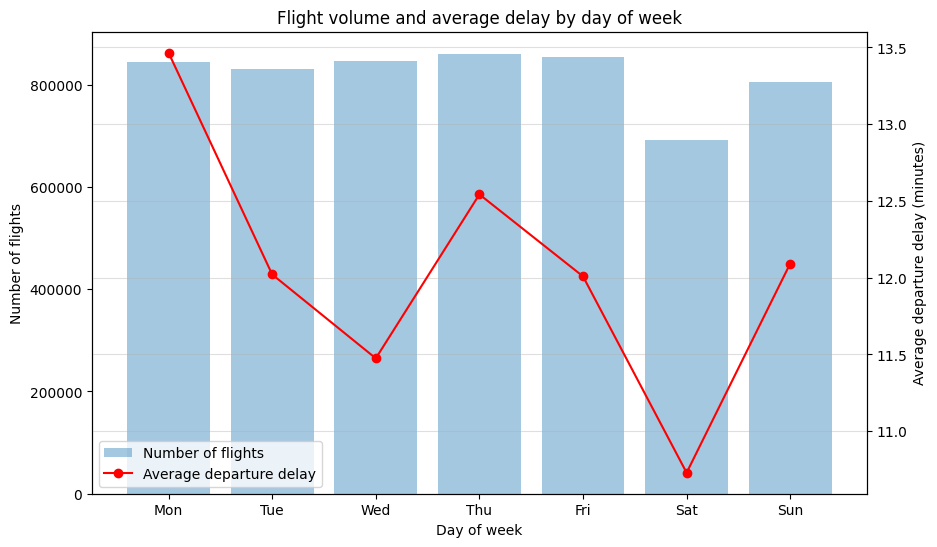

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/flights.csv", low_memory = False)
df_delays = df[df["CANCELLED"] == 0].copy()
df_delays["DEPARTURE_DELAY_POSITIVE"] = df_delays["DEPARTURE_DELAY"].clip(lower = 0)

weekday_delay = df_delays.groupby("DAY_OF_WEEK")["DEPARTURE_DELAY_POSITIVE"].mean()
weekday_flights = df_delays.groupby("DAY_OF_WEEK").size()

weekday_delay = weekday_delay.sort_index()
weekday_flights = weekday_flights.sort_index()

fig, ax1 = plt.subplots(figsize = (10,6))
bars = ax1.bar(weekday_flights.index, weekday_flights.values, alpha = 0.4)
ax1.set_xlabel("Day of week")
ax1.set_ylabel("Number of flights")
ax1.set_xticks(range(1, 8))
ax1.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax2 = ax1.twinx()
line, = ax2.plot(weekday_delay.index, weekday_delay.values, color = "red", marker = "o")
ax2.set_ylabel("Average departure delay (minutes)")
plt.grid(True, alpha = 0.4)
ax1.legend([bars, line], ["Number of flights", "Average departure delay"], loc = "lower left")
plt.title("Flight volume and average delay by day of week")

plt.show()


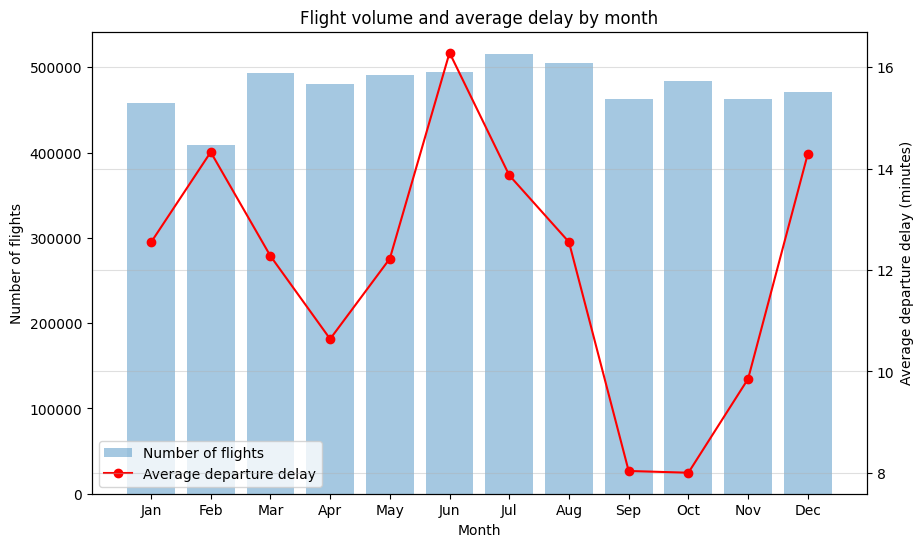

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/flights.csv", low_memory = False)
df_delays = df[df["CANCELLED"] == 0].copy()
df_delays["DEPARTURE_DELAY_POSITIVE"] = df_delays["DEPARTURE_DELAY"].clip(lower = 0)

month_delay = df_delays.groupby("MONTH")["DEPARTURE_DELAY_POSITIVE"].mean()
month_flights = df_delays.groupby("MONTH").size()

month_delay = month_delay.sort_index()
month_flights = month_flights.sort_index()

fig, ax1 = plt.subplots(figsize = (10,6))
bars = ax1.bar(month_flights.index, month_flights.values, alpha = 0.4)
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of flights")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug",
                    "Sep", "Oct", "Nov", "Dec"])
ax2 = ax1.twinx()
line, = ax2.plot(month_delay.index, month_delay.values, color = "red", marker = "o")
ax2.set_ylabel("Average departure delay (minutes)")
plt.grid(True, alpha = 0.4)
ax1.legend([bars, line], ["Number of flights", "Average departure delay"], loc = "lower left")
plt.title("Flight volume and average delay by month")

plt.show()




1.   The analysis shows that the average departure delay increases as the day progresses. At the same time, the number of flights remains relatively stable during most daytime hours and does not exhibit a strong relationship with the magnitude of delays. This suggests that the main reason for the increase in delays is the accumulation of delays from previous flights. If an aircraft arrives late from a previous flight, this often leads to a delayed departure of the next flight, creating a cascading effect of delays throughout the operational day.

2.   The distribution of delays by day of the week shows that the average delay is higher at the beginning of the workweek, particularly on Mondays. This may be associated with increased business activity and a denser flight schedule following the weekend. At the same time, during the weekend - especially on Saturdays - the number of flights is lower and the average delays are smaller, which may indicate a reduced load on the aviation infrastructure.

3. The seasonal analysis shows that the number of flights remains relatively stable throughout the year. However, the average departure delay exhibits noticeable fluctuations. In particular, delays increase during the summer months and again in December. These patterns may be related to seasonal factors such as higher passenger demand during the vacation period and the Christmas and New Year holidays, as well as potential weather-related disruptions.



# Causes of Flight Cancellations

Let's investigate the main factors responsible for cancelled flights. Identifying the dominant causes of cancellations can help reveal structural weaknesses in the aviation system and support better decision-making by transportation authorities.

CANCELLATION_REASON
Weather       48851
Airline       25262
Air System    15749
Security         22
Name: count, dtype: int64


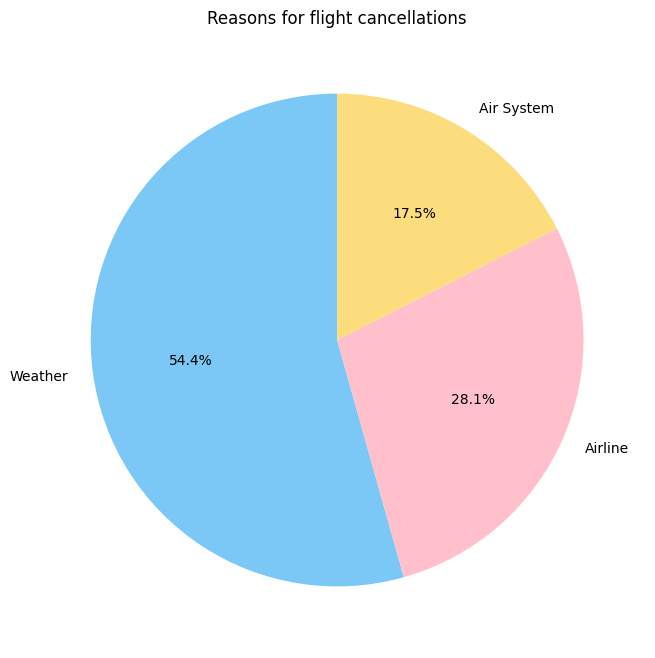

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/flights.csv", low_memory = False)
df_cancelled = df[df["CANCELLED"] == 1].copy()

reason_labels = {"A": "Airline", "B": "Weather",
                 "C": "Air System", "D": "Security"}

cancel_reasons = df_cancelled["CANCELLATION_REASON"].value_counts()
cancel_reasons.index = cancel_reasons.index.map(reason_labels)
print(cancel_reasons)
cancel_reasons = cancel_reasons.drop("Security")

plt.figure(figsize = (8, 8))
plt.pie(cancel_reasons.values, labels = cancel_reasons.index,
        autopct = "%1.1f%%", startangle = 90, colors = ["#7BC8F6", "#FFC0CB", "#FBDD7E"])
plt.title("Reasons for flight cancellations")

plt.show()



The analysis of flight cancellations shows that the majority of cancellations are caused by weather conditions, which account for more than half of all cancelled flights.

The second most significant cause of cancellations is airline-related issues, which may include operational problems such as crew availability, aircraft maintenance, or scheduling difficulties. The substantial share of such cancellations suggests that improvements in operational planning and resource management by airlines could potentially reduce the number of cancelled flights.

Another noticeable portion of cancellations is associated with air system constraints, which may reflect congestion in air traffic control systems or limitations of airport infrastructure. This indicates that increasing the efficiency and capacity of the national air transportation system could also help reduce disruptions.

Cancellations due to security reasons represent a negligible fraction of the total (less than 0.1%) and were therefore excluded from the visualization.

# Airline Performance: Delays and Cancellations

In this section, I analyze airline performance in terms of operational disruptions. Specifically, I examine which airlines experience the highest number of flight cancellations and which airlines have the largest average departure delays.


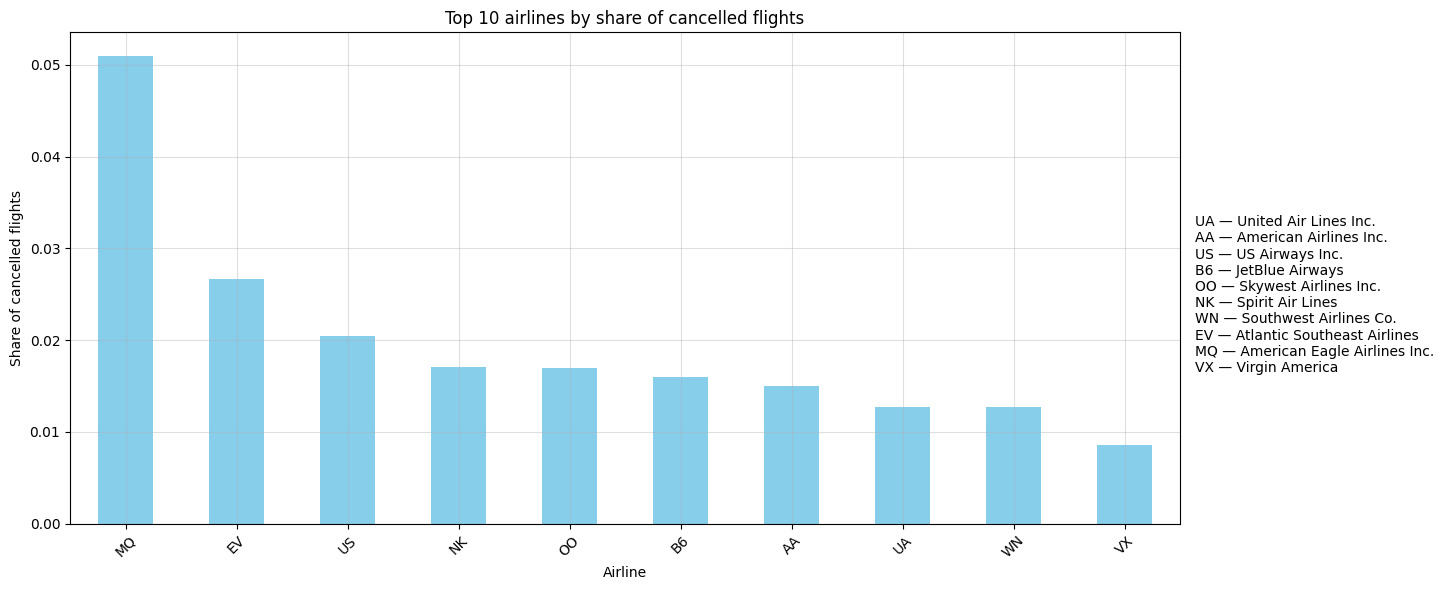

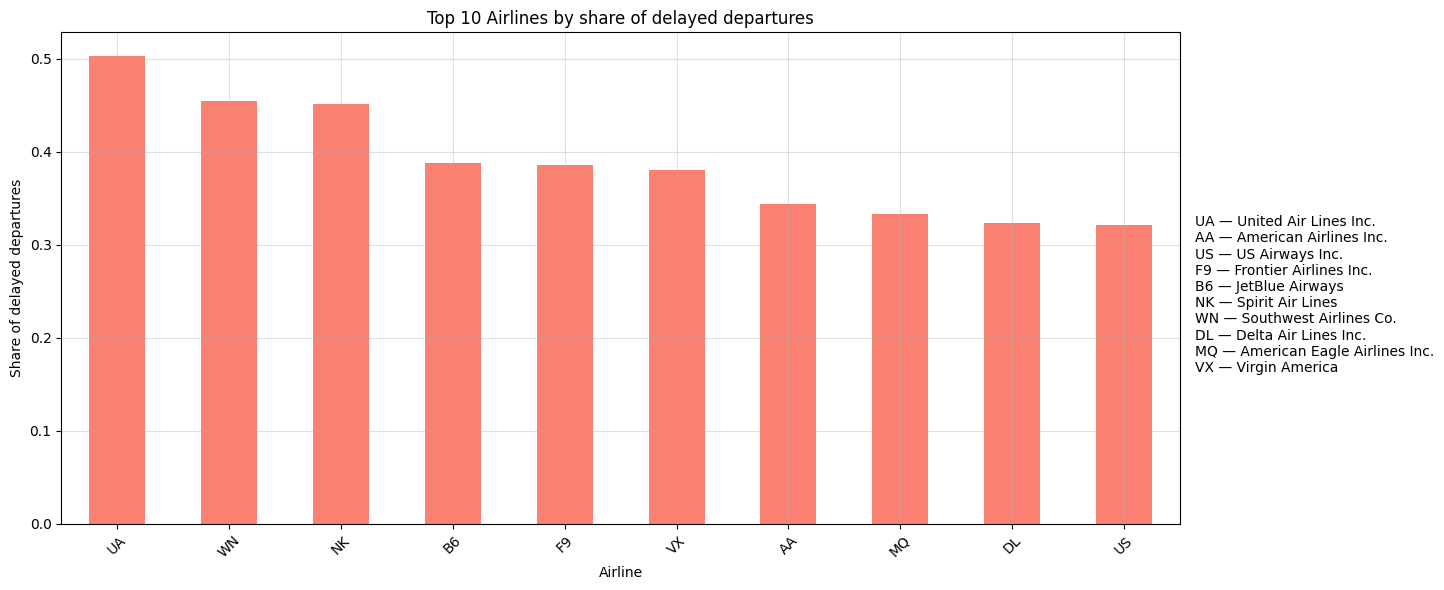

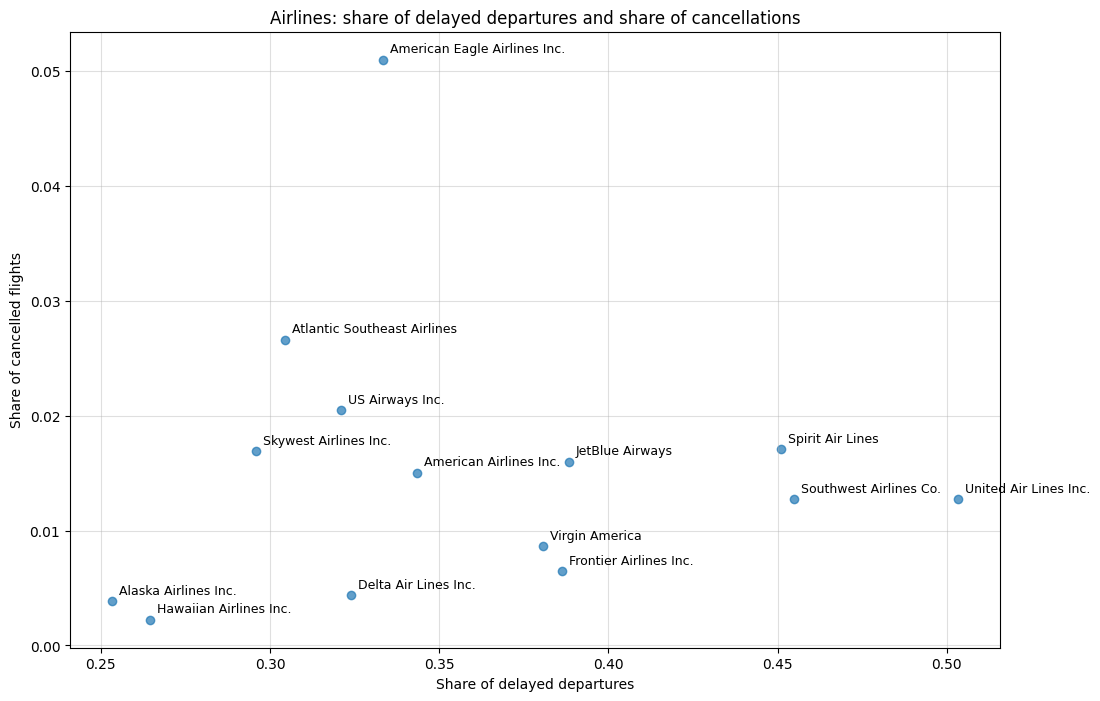

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/flights.csv", low_memory = False)
airlines = pd.read_csv("/content/drive/MyDrive/airlines.csv")
df = df.merge(airlines, left_on = "AIRLINE", right_on = "IATA_CODE", how = "left")

df["AIRLINE_CODE"] = df["AIRLINE_x"]
df["AIRLINE_NAME"] = df["AIRLINE_y"]

share_of_cancel = df.groupby("AIRLINE_CODE")["CANCELLED"].mean().sort_values(ascending = False)

df_not_cancelled = df[(df["CANCELLED"] == 0) & (df["DEPARTURE_DELAY"].notna())].copy()
df_not_cancelled["IS_DELAYED"] = (df_not_cancelled["DEPARTURE_DELAY"] > 0).astype(int)

share_of_delay = df_not_cancelled.groupby("AIRLINE_CODE")["IS_DELAYED"].mean()
share_of_delay = share_of_delay.sort_values(ascending = False)

top10_cancel_share = share_of_cancel.head(10)
top10_delay_share = share_of_delay.head(10)

plt.figure(figsize = (12, 6))
top10_cancel_share.plot(kind = "bar", color = "skyblue")

plt.title("Top 10 airlines by share of cancelled flights")
plt.xlabel("Airline")
plt.ylabel("Share of cancelled flights")
plt.xticks(rotation = 45)
plt.grid(True, alpha = 0.4)

legend_text = "\n".join(f"{row.IATA_CODE} — {row.AIRLINE}"
    for _, row in airlines[airlines["IATA_CODE"].isin(top10_cancel_share.index)].iterrows())
plt.gcf().text(1, 0.5, legend_text, fontsize = 10, va = "center")
plt.tight_layout()
plt.show()

plt.figure(figsize = (12, 6))
top10_delay_share.plot(kind = "bar", color = "salmon")

plt.title("Top 10 Airlines by share of delayed departures")
plt.xlabel("Airline")
plt.ylabel("Share of delayed departures")
plt.xticks(rotation = 45)
plt.grid(True, alpha = 0.4)

legend_text = "\n".join(f"{row.IATA_CODE} — {row.AIRLINE}"
    for _, row in airlines[airlines["IATA_CODE"].isin(top10_delay_share.index)].iterrows())
plt.gcf().text(1, 0.5, legend_text, fontsize = 10, va = "center")
plt.tight_layout()
plt.show()

cancel_stats = df.groupby("AIRLINE_NAME")["CANCELLED"].mean().rename("CANCEL_SHARE")
delay_stats = df_not_cancelled.groupby("AIRLINE_NAME")["IS_DELAYED"].mean().rename("DELAY_SHARE")
airline_stats = pd.concat([cancel_stats, delay_stats], axis = 1).dropna()

plt.figure(figsize = (12, 8))
plt.scatter(airline_stats["DELAY_SHARE"], airline_stats["CANCEL_SHARE"], alpha = 0.7)

for airline, row in airline_stats.iterrows():
    plt.annotate(airline, (row["DELAY_SHARE"], row["CANCEL_SHARE"]), xytext = (5, 5),
        textcoords = "offset points",
        fontsize = 9
    )

plt.title("Airlines: share of delayed departures and share of cancellations")
plt.xlabel("Share of delayed departures")
plt.ylabel("Share of cancelled flights")
plt.grid(True, alpha = 0.4)
plt.show()



For a fair comparison of airlines, I used the shares of cancellations and delays rather than their absolute numbers. This approach makes it possible to identify carriers whose problems are systematic, rather than simply related to operating a large number of flights.

The analysis shows that the airline with the highest share of cancelled flights is American Eagle Airlines Inc. (MQ) - about 5% of its flights are cancelled, which is significantly higher than for other carriers. A relatively high cancellation rate is also observed for Atlantic Southeast Airlines (EV) and US Airways Inc. (US).

In terms of the share of delayed departures, the most serious problems are observed for United Air Lines Inc. (UA), where more than 50% of flights depart with a delay. A high share of delays is also characteristic of Southwest Airlines (WN) and Spirit Air Lines (NK).

At the same time, airlines such as Hawaiian Airlines and Alaska Airlines demonstrate significantly lower shares of both delays and cancellations, indicating a more stable performance of their flight operations.

# Airports with the highest delay rates

In addition to airline performance, flight delays may also be related to congestion at specific airports. Therefore, it is important to analyze whether certain airports systematically experience a higher share of delayed departures.
To investigate this, I calculate the share of delayed departures for each origin airport. In addition, to better understand the reasons behind these delays, I analyze the distribution of delay causes for the airports with the highest delay rates.

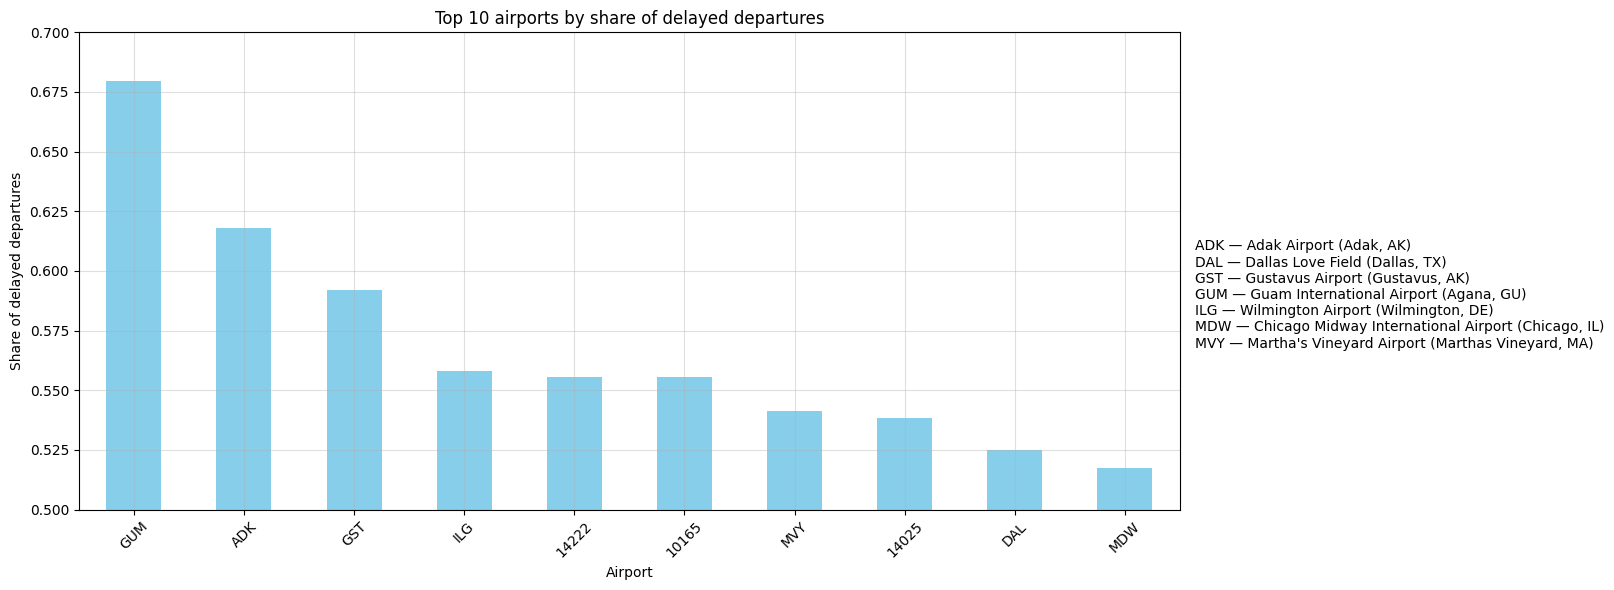

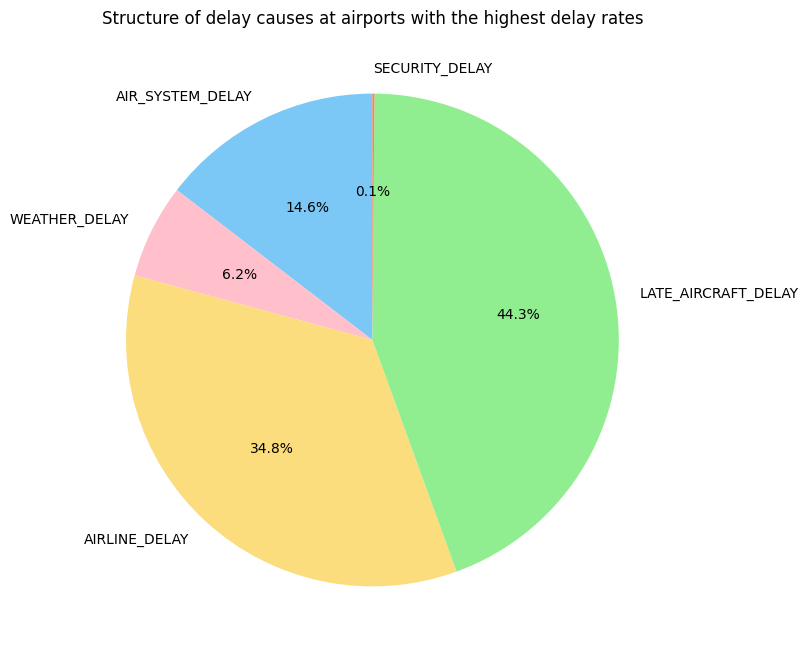

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/flights.csv", low_memory = False)
airports = pd.read_csv("/content/drive/MyDrive/airports.csv")

df_not_cancelled = df[(df["CANCELLED"] == 0) & (df["DEPARTURE_DELAY"].notna())].copy()
df_not_cancelled["IS_DELAYED"] = (df_not_cancelled["DEPARTURE_DELAY"] > 0).astype(int)

airport_delay_share = df_not_cancelled.groupby("ORIGIN_AIRPORT")["IS_DELAYED"].mean().sort_values(ascending = False)
top10_airports = airport_delay_share.head(10)

df_top_airports_delayed = df_not_cancelled[
    (df_not_cancelled["ORIGIN_AIRPORT"].isin(top10_airports.index)) &
    (df_not_cancelled["DEPARTURE_DELAY"] > 0)
].copy()

delay_reasons = df_top_airports_delayed[
    ["AIR_SYSTEM_DELAY", "WEATHER_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "SECURITY_DELAY"]
].sum()

plt.figure(figsize = (12,6))
top10_airports.plot(kind = "bar", color = "skyblue")
plt.title("Top 10 airports by share of delayed departures")
plt.xlabel("Airport")
plt.ylabel("Share of delayed departures")
plt.xticks(rotation = 45)
plt.grid(True, alpha = 0.4)
plt.ylim(0.5, 0.7)

legend_text = "\n".join(f"{row.IATA_CODE} — {row.AIRPORT} ({row.CITY}, {row.STATE})"
    for _, row in airports[airports["IATA_CODE"].isin(top10_airports.index)].iterrows()
)
plt.gcf().text(1, 0.5, legend_text, fontsize = 10, va = "center")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,8))
plt.pie(delay_reasons, labels = delay_reasons.index, autopct = "%1.1f%%", startangle = 90,
        colors = ["#7BC8F6", "#FFC0CB", "#FBDD7E",  "lightgreen", "coral"])
plt.title("Structure of delay causes at airports with the highest delay rates")
plt.show()


The analysis shows that several airports have a very high share of delayed departures. In particular, airports such as Guam International Airport (GUM), Adak Airport (ADK), and Gustavus Airport (GST) demonstrate the highest delay rates among all airports in the dataset.

To understand the underlying reasons for these delays, the structure of delay causes was analyzed for flights departing from these airports. The results show that the largest share of total delay minutes is associated with late arriving aircraft, which accounts for approximately 44% of all delay time. This indicates that delays often propagate through the flight network when aircraft arrive late from previous flights. The second most significant factor is airline-related delays, responsible for about 35% of total delay minutes, suggesting that operational issues within airlines also play an important role. Air system delays account for roughly 15%, while weather-related delays contribute around 6%. Security delays represent a negligible share of the total delay time.

Overall, the results suggest that delays at the airports with the highest delay rates are largely driven by network effects and airline operations rather than external factors such as weather or security issues.

# Most problematic flight routes

In addition to analyzing delays by airlines and airports, it is also useful to examine delays at the level of specific flight routes. Some origin–destination pairs may experience systematic delays due to congestion, scheduling constraints, weather conditions, or operational factors.
To investigate this, I calculate the share of delayed departures for each route.

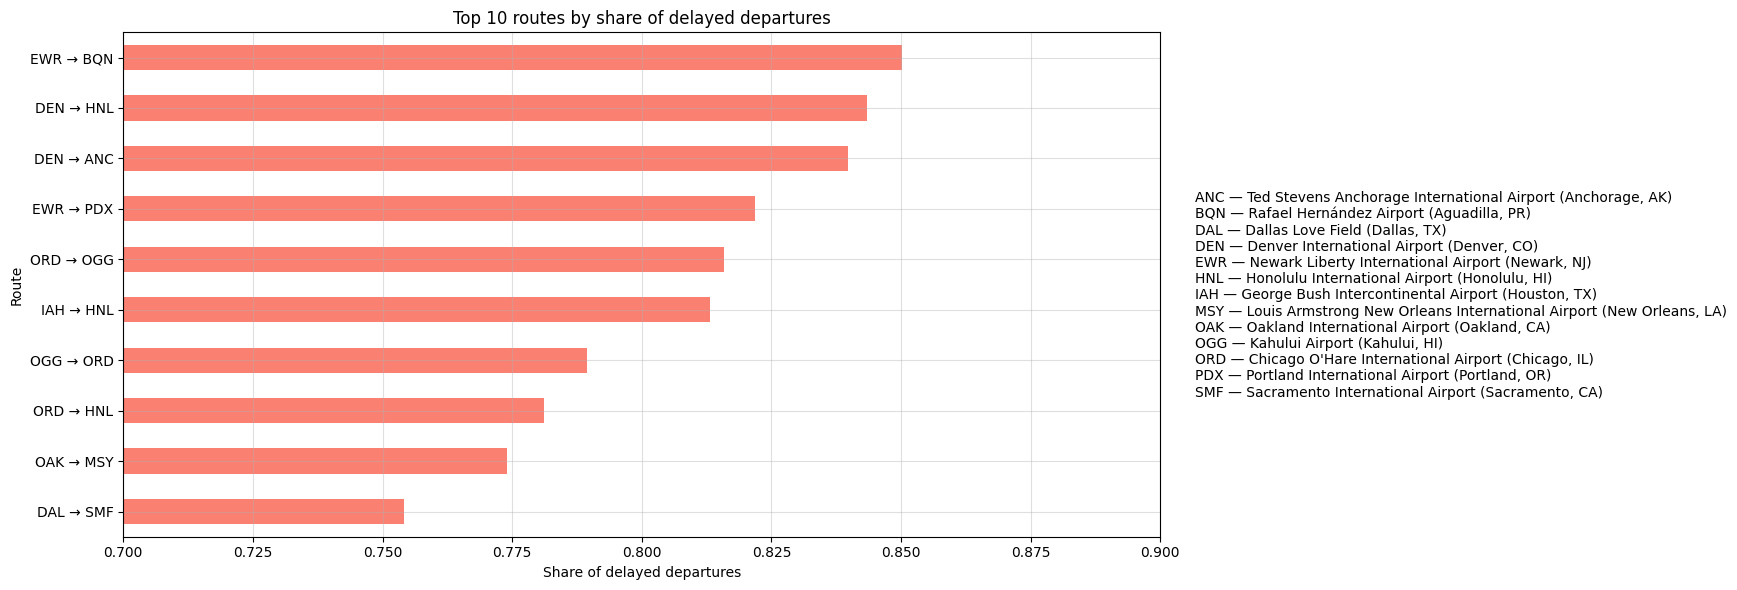

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/flights.csv", low_memory=False)
airports = pd.read_csv("/content/drive/MyDrive/airports.csv")

df_not_cancelled = df[(df["CANCELLED"] == 0) & (df["DEPARTURE_DELAY"].notna())].copy()
df_not_cancelled["IS_DELAYED"] = (df_not_cancelled["DEPARTURE_DELAY"] > 0).astype(int)
df_not_cancelled["ROUTE"] = df_not_cancelled["ORIGIN_AIRPORT"] + " → " + df_not_cancelled["DESTINATION_AIRPORT"]

route_stats = df_not_cancelled.groupby("ROUTE").agg(
    delay_share = ("IS_DELAYED", "mean"),
    flights = ("IS_DELAYED", "count")
)

route_stats = route_stats[route_stats["flights"] >= 100]
route_stats = route_stats.sort_values("delay_share", ascending = False)
top10_routes = route_stats.head(10)

plt.figure(figsize = (12,6))
top10_routes["delay_share"].sort_values().plot(kind = "barh", color = "salmon")
plt.title("Top 10 routes by share of delayed departures")
plt.xlabel("Share of delayed departures")
plt.ylabel("Route")
plt.xlim(0.7, 0.9)
plt.grid(True, alpha = 0.4)

airport_codes = set()
for route in top10_routes.index:
    origin, dest = route.split(" → ")
    airport_codes.add(origin)
    airport_codes.add(dest)

legend_text = "\n".join(
    f"{row.IATA_CODE} — {row.AIRPORT} ({row.CITY}, {row.STATE})"
    for _, row in airports[airports["IATA_CODE"].isin(airport_codes)].iterrows()
)

plt.gcf().text(1, 0.5, legend_text, fontsize=10, va = "center")
plt.tight_layout()
plt.show()

The analysis of flight routes shows that some origin–destination pairs systematically experience a very high share of delayed departures. The highest delay rate is observed for the route EWR → BQN (Newark Liberty International Airport - Rafael Hernández Airport), where about 85% of flights depart with delays.

Several other routes also demonstrate high delay rates, including DEN → HNL, DEN → ANC, and EWR → PDX, where more than 80% of departures are delayed. Many of these routes connect large mainland hubs with distant destinations such as Alaska, Hawaii, or Puerto Rico, which may increase operational complexity and contribute to delays.